# EEG Seizure Detection — Transformer Classifier

This notebook adds a **Transformer-based classifier** to the existing EEG seizure detection pipeline and compares all three models:
1. **1D CNN** (baseline — loaded from saved model)
2. **Bayesian-Optimized SVM** (baseline — loaded from saved model)
3. **Transformer** (new — trained on **raw EEG signals**, not hand-crafted features)



## 1. Setup & Imports

In [1]:
import os, json, time, warnings, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, balanced_accuracy_score, matthews_corrcoef,
    roc_curve, f1_score
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = ['Healthy', 'Interictal', 'Ictal']
N_CLASSES   = 3

TensorFlow : 2.20.0
NumPy      : 2.4.2


## 2. Load Raw EEG Signals for the Transformer

The Bonn dataset has 500 single-channel EEG segments (4097 samples each @ 173.61 Hz).
We load them from `dataset/`, apply a Butterworth bandpass filter (0.5–60 Hz), and z-score normalise each segment.

In [3]:
import os
os.chdir('/users/shruthinagappan/documents/eeg-seizure-prediction')

In [5]:
from scipy.signal import butter, filtfilt

DATASET_DIR = 'dataset'   # adjust if needed
FOLDERS     = {'Z': 0, 'O': 0, 'N': 1, 'F': 1, 'S': 2}
FS          = 173.61

def bandpass(signal, lowcut=0.5, highcut=60.0, fs=FS, order=4):
    nyq  = fs / 2
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, signal)

signals, labels = [], []

for folder, label in FOLDERS.items():
    folder_path = os.path.join(DATASET_DIR, folder)
    if not os.path.isdir(folder_path):
        raise FileNotFoundError(
            f"Cannot find '{folder_path}'. "
            "Ensure the Bonn dataset folders (Z, O, N, F, S) are inside 'dataset/'."
        )
    files = sorted([f for f in os.listdir(folder_path) if f.endswith('.txt')  or f.endswith('.TXT')])
    for fname in files:
        raw      = np.loadtxt(os.path.join(folder_path, fname))
        filtered = bandpass(raw)
        filtered = (filtered - filtered.mean()) / (filtered.std() + 1e-8)
        signals.append(filtered)
        labels.append(label)
    print(f'  Set {folder}: {len(files)} files  →  class {label} ({CLASS_NAMES[label]})')

signals = np.array(signals)
labels  = np.array(labels)
print(f'\nRaw signals : {signals.shape}  |  labels: {np.unique(labels, return_counts=True)}')

  Set Z: 100 files  →  class 0 (Healthy)
  Set O: 100 files  →  class 0 (Healthy)
  Set N: 100 files  →  class 1 (Interictal)
  Set F: 100 files  →  class 1 (Interictal)
  Set S: 100 files  →  class 2 (Ictal)

Raw signals : (500, 4097)  |  labels: (array([0, 1, 2]), array([200, 200, 100]))


## 3. Window the Signals

4097 timesteps is too long for self-attention on modest hardware.
We slice each segment into non-overlapping **256-sample windows** (~1.5 s),
giving ~16 windows per segment and ~8 000 total samples — giving the Transformer enough data to learn from.

In [6]:
WINDOW = 256
STRIDE = 256   # non-overlapping

X_wins, y_wins = [], []
for sig, lbl in zip(signals, labels):
    for start in range(0, len(sig) - WINDOW + 1, STRIDE):
        X_wins.append(sig[start : start + WINDOW])
        y_wins.append(lbl)

X_wins = np.array(X_wins)[..., np.newaxis]   # (N, 256, 1)
y_wins = np.array(y_wins)

print(f'Windowed dataset : {X_wins.shape}  |  class counts: {np.unique(y_wins, return_counts=True)}')

X_tr, X_te, y_tr, y_te = train_test_split(
    X_wins, y_wins, test_size=0.20, random_state=SEED, stratify=y_wins
)

y_tr_oh  = to_categorical(y_tr, N_CLASSES)
y_te_oh  = to_categorical(y_te, N_CLASSES)
y_te_bin = label_binarize(y_te, classes=[0, 1, 2])

T = X_tr.shape[1]   # 256
C = X_tr.shape[2]   # 1

print(f'Train : {X_tr.shape}   Test : {X_te.shape}')

Windowed dataset : (8000, 256, 1)  |  class counts: (array([0, 1, 2]), array([3200, 3200, 1600]))
Train : (6400, 256, 1)   Test : (1600, 256, 1)


## 4. Load Existing CNN & SVM Models

In [7]:
# Load preprocessed feature arrays (used by CNN / SVM)
X_feat_test = np.load('X_test.npy')
y_feat_test = np.load('y_test.npy')
y_feat_bin  = label_binarize(y_feat_test, classes=[0, 1, 2])
X_feat_dl   = X_feat_test[..., np.newaxis] if X_feat_test.ndim == 2 else X_feat_test
X_feat_flat = X_feat_test if X_feat_test.ndim == 2 else X_feat_test.reshape(len(X_feat_test), -1)

# ── CNN ───────────────────────────────────────────────────────────────────────
try:
    cnn_model = keras.models.load_model('epilepsy_cnn_model.keras')
    cnn_probs = cnn_model.predict(X_feat_dl, verbose=0)
    cnn_preds = np.argmax(cnn_probs, axis=1)
    cnn_acc   = accuracy_score(y_feat_test, cnn_preds)
    cnn_auc   = roc_auc_score(y_feat_bin, cnn_probs, multi_class='ovr', average='macro')
    cnn_mcc   = matthews_corrcoef(y_feat_test, cnn_preds)
    cnn_bal   = balanced_accuracy_score(y_feat_test, cnn_preds)
    print(f'CNN  Acc={cnn_acc:.4f}  AUC={cnn_auc:.4f}  MCC={cnn_mcc:.4f}')
except Exception as e:
    print(f'CNN not loaded ({e}) — using published results.')
    cnn_acc, cnn_auc, cnn_mcc, cnn_bal = 0.9504, 0.9901, 0.9268, 0.9500
    cnn_preds = cnn_probs = None

# ── SVM ───────────────────────────────────────────────────────────────────────
try:
    with open('svm_epilepsy_model.pkl', 'rb') as f:
        svm_model = pickle.load(f)
    svm_preds = svm_model.predict(X_feat_flat)
    svm_probs = svm_model.predict_proba(X_feat_flat) if hasattr(svm_model, 'predict_proba') else None
    svm_acc   = accuracy_score(y_feat_test, svm_preds)
    svm_auc   = roc_auc_score(y_feat_bin, svm_probs, multi_class='ovr', average='macro') if svm_probs is not None else np.nan
    svm_mcc   = matthews_corrcoef(y_feat_test, svm_preds)
    svm_bal   = balanced_accuracy_score(y_feat_test, svm_preds)
    print(f'SVM  Acc={svm_acc:.4f}  AUC={svm_auc:.4f}  MCC={svm_mcc:.4f}')
except Exception as e:
    print(f'SVM not loaded ({e}) — using published results.')
    svm_acc, svm_auc, svm_mcc, svm_bal = 0.9917, 0.9983, 0.9877, 0.9917
    svm_preds = svm_probs = None

CNN  Acc=0.9504  AUC=0.9901  MCC=0.9268
SVM  Acc=0.9917  AUC=0.9983  MCC=0.9877


## 5. Transformer Architecture

```
Raw EEG window  (256 timesteps × 1 channel)
  └─► Conv1D(64, k=7) + LayerNorm     ← local patch embedding
      └─► Learnable Positional Encoding
          └─► TransformerBlock × 4
              ├─ MultiHeadAttention (4 heads, key_dim=16)
              ├─ Add & LayerNorm
              ├─ FFN  Dense(256→64)
              └─ Add & LayerNorm
          └─► GlobalAveragePooling1D
              └─► Dense(64, relu) → Dropout(0.3) → Dense(3, softmax)
```

In [8]:
class PositionalEncoding(layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.pos_emb = self.add_weight(
            name='pos_emb', shape=(1, seq_len, d_model),
            initializer='random_normal', trainable=True
        )
    def call(self, x):
        return x + self.pos_emb


class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.attn  = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout
        )
        self.ff    = keras.Sequential([
            layers.Dense(d_ff, activation='relu'),
            layers.Dropout(dropout),
            layers.Dense(d_model)
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn_out = self.attn(x, x, training=training)
        x = self.norm1(x + self.drop1(attn_out, training=training))
        ff_out = self.ff(x, training=training)
        return self.norm2(x + self.drop2(ff_out, training=training))


def build_transformer(seq_len, in_ch, n_classes,
                      d_model=64, num_heads=4, d_ff=256, n_layers=4, dropout=0.2):
    inp = keras.Input(shape=(seq_len, in_ch))
    # Patch embedding: Conv1D extracts local features before attention
    x = layers.Conv1D(d_model, kernel_size=7, padding='same', activation='relu')(inp)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = PositionalEncoding(seq_len, d_model)(x)
    x = layers.Dropout(dropout)(x)
    for i in range(n_layers):
        x = TransformerBlock(d_model, num_heads, d_ff, dropout, name=f'block_{i}')(x)
    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(dropout)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return Model(inp, out, name='EEG_Transformer')


transformer = build_transformer(T, C, N_CLASSES)
transformer.summary()

Model: "EEG_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 256, 64)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 256, 64)        │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 256, 64)        │        16,384 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_0 (TransformerBlock)      │ (None, 256, 64)        │        49,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_1 (TransformerBlock)      │ (None, 256, 64)        │        49,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_2 (TransformerBlock)      │ (None, 256, 64)        │        49,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_3 (TransformerBlock)      │ (None, 256, 64)        │        49,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,315 (864.51 KB)

 Trainable params: 221,315 (864.51 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Transformer

In [9]:
transformer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

os.makedirs('checkpoints', exist_ok=True)
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=7, min_lr=1e-6, verbose=1),
    ModelCheckpoint('checkpoints/best_transformer.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=0)
]

t0 = time.time()
history = transformer.fit(
    X_tr, y_tr_oh,
    validation_split=0.15,
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)
print(f'\nTraining time: {time.time()-t0:.1f}s')

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 58s 610ms/step - accuracy: 0.7188 - loss: 0.6807 - val_accuracy: 0.7229 - val_loss: 0.6389 - learning_rate: 5.0000e-04
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 56s 660ms/step - accuracy: 0.7638 - loss: 0.5670 - val_accuracy: 0.7812 - val_loss: 0.5160 - learning_rate: 5.0000e-04
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 59s 690ms/step - accuracy: 0.8233 - loss: 0.4551 - val_accuracy: 0.8729 - val_loss: 0.3352 - learning_rate: 5.0000e-04
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 67s 794ms/step - accuracy: 0.8792 - loss: 0.3302 - val_accuracy: 0.8781 - val_loss: 0.3179 - learning_rate: 5.0000e-04
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 71s 832ms/step - accuracy: 0.9068 - loss: 0.2670 - val_accuracy: 0.8323 - val_loss: 0.4756 - learning_rate: 5.0000e-04
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 73s 864ms/step - accuracy: 0.9096 - loss: 0.2497 - val_accuracy: 0.8781 - val_loss: 0.3512 - learning_rate: 5.0000e-04
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 81s 949ms/ste

## 7. Training Curves

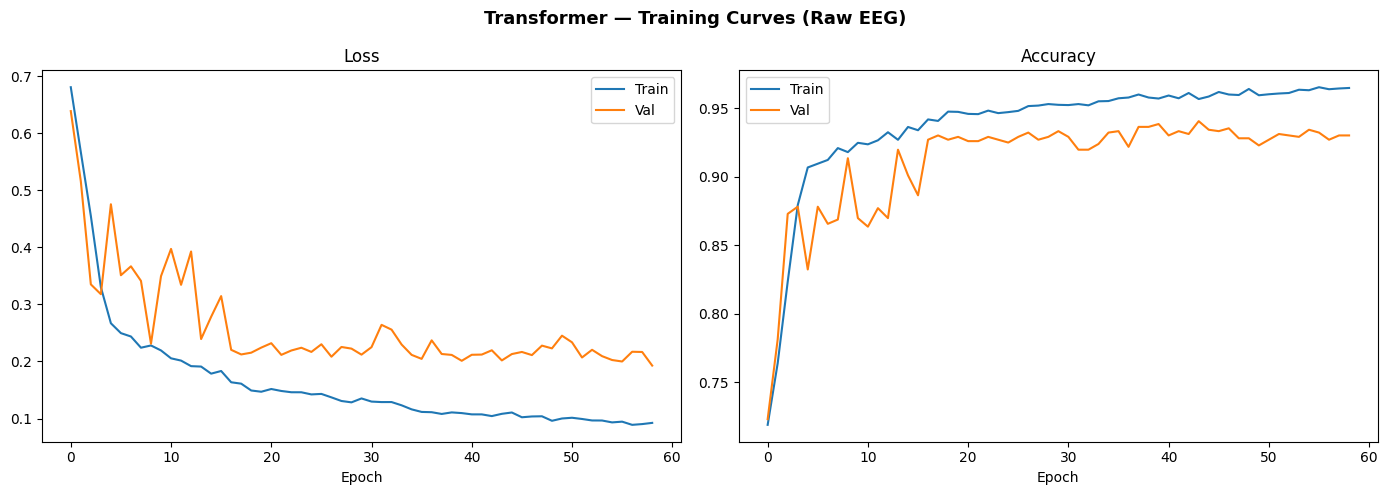

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transformer — Training Curves (Raw EEG)', fontsize=13, fontweight='bold')
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('transformer_training_curves.png', dpi=150)
plt.show()

## 8. Evaluate Transformer

In [11]:
trans_probs = transformer.predict(X_te, verbose=0)
trans_preds = np.argmax(trans_probs, axis=1)
trans_loss, _ = transformer.evaluate(X_te, y_te_oh, verbose=0)

trans_acc  = accuracy_score(y_te, trans_preds)
trans_auc  = roc_auc_score(y_te_bin, trans_probs, multi_class='ovr', average='macro')
trans_mcc  = matthews_corrcoef(y_te, trans_preds)
trans_bal  = balanced_accuracy_score(y_te, trans_preds)

print('=== Transformer Test Results (Raw EEG) ===')
print(f'Loss              : {trans_loss:.4f}')
print(f'Accuracy          : {trans_acc:.4f}')
print(f'Balanced Accuracy : {trans_bal:.4f}')
print(f'Macro AUC         : {trans_auc:.4f}')
print(f'MCC               : {trans_mcc:.4f}')
print()
print(classification_report(y_te, trans_preds, target_names=CLASS_NAMES))

=== Transformer Test Results (Raw EEG) ===
Loss              : 0.1394
Accuracy          : 0.9525
Balanced Accuracy : 0.9531
Macro AUC         : 0.9933
MCC               : 0.9258

              precision    recall  f1-score   support

     Healthy       0.95      0.95      0.95       640
  Interictal       0.95      0.95      0.95       640
       Ictal       0.96      0.96      0.96       320

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



## 9. Transformer Confusion Matrix & ROC

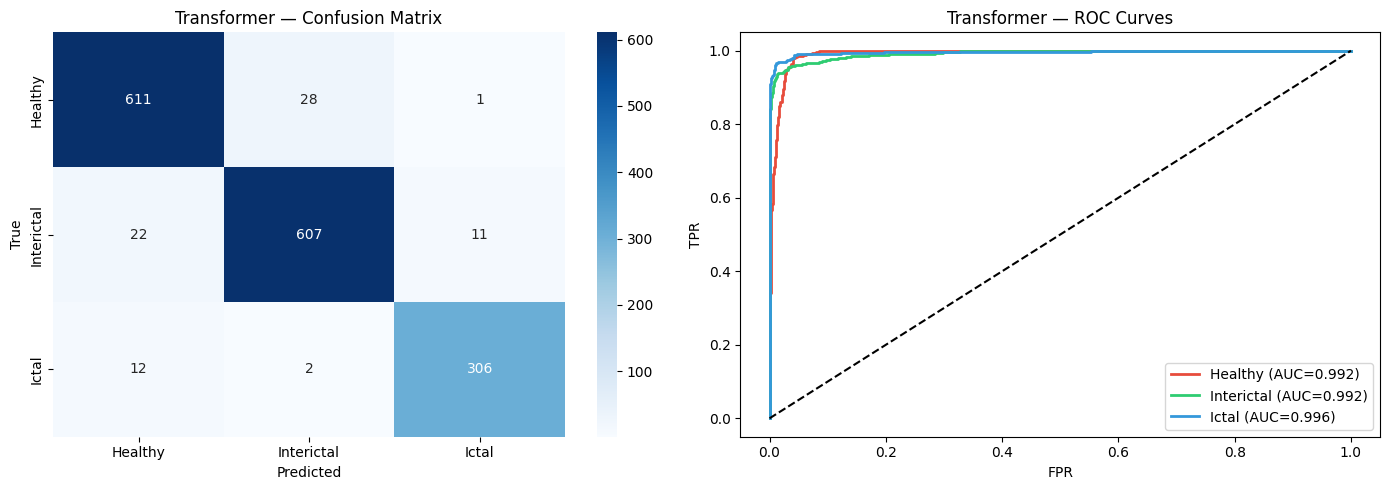

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_te, trans_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Transformer — Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

colors = ['#e74c3c', '#2ecc71', '#3498db']
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_te_bin[:, i], trans_probs[:, i])
    axes[1].plot(fpr, tpr, color=col, lw=2,
                 label=f'{cls} (AUC={roc_auc_score(y_te_bin[:, i], trans_probs[:, i]):.3f})')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Transformer — ROC Curves'); axes[1].legend(loc='lower right')
plt.tight_layout()
plt.savefig('transformer_evaluation.png', dpi=150)
plt.show()

## 10. Full Model Comparison

In [13]:
results = {
    '1D CNN': {
        'Accuracy': cnn_acc, 'Macro AUC': cnn_auc,
        'Balanced Accuracy': cnn_bal, 'MCC': cnn_mcc,
        'preds': cnn_preds, 'probs': cnn_probs,
        'y_true': y_feat_test if cnn_preds is not None else None,
        'y_bin':  y_feat_bin  if cnn_preds is not None else None,
        'color': '#3498db'
    },
    'SVM (Bayesian)': {
        'Accuracy': svm_acc, 'Macro AUC': svm_auc,
        'Balanced Accuracy': svm_bal, 'MCC': svm_mcc,
        'preds': svm_preds, 'probs': svm_probs,
        'y_true': y_feat_test if svm_preds is not None else None,
        'y_bin':  y_feat_bin  if svm_preds is not None else None,
        'color': '#e67e22'
    },
    'Transformer': {
        'Accuracy': trans_acc, 'Macro AUC': trans_auc,
        'Balanced Accuracy': trans_bal, 'MCC': trans_mcc,
        'preds': trans_preds, 'probs': trans_probs,
        'y_true': y_te, 'y_bin': y_te_bin,
        'color': '#9b59b6'
    }
}

metrics = ['Accuracy', 'Macro AUC', 'Balanced Accuracy', 'MCC']
models  = list(results.keys())

print('\n' + '═'*68)
print(' FINAL MODEL COMPARISON — EEG Seizure Detection')
print('═'*68)
print(f"{'Metric':<22}" + ''.join(f"{m:>15}" for m in models))
print('─'*68)
for met in metrics:
    row = f'{met:<22}'
    for m in models:
        v = results[m][met]
        try:
            row += f'{float(v):>15.4f}'
        except (TypeError, ValueError):
            row += f"{'N/A':>15}"
    print(row)
print('═'*68)

best_acc = max(models, key=lambda m: results[m]['Accuracy'])
best_auc = max(models, key=lambda m: float(results[m]['Macro AUC'] or 0))
print(f'\n Best Accuracy : {best_acc} ({results[best_acc]["Accuracy"]:.4f})')
print(f'Best AUC      : {best_auc} ({results[best_auc]["Macro AUC"]:.4f})')


════════════════════════════════════════════════════════════════════
 FINAL MODEL COMPARISON — EEG Seizure Detection
════════════════════════════════════════════════════════════════════
Metric                         1D CNN SVM (Bayesian)    Transformer
────────────────────────────────────────────────────────────────────
Accuracy                       0.9504         0.9917         0.9525
Macro AUC                      0.9901         0.9983         0.9933
Balanced Accuracy              0.9500         0.9917         0.9531
MCC                            0.9268         0.9877         0.9258
════════════════════════════════════════════════════════════════════

 Best Accuracy : SVM (Bayesian) (0.9917)
Best AUC      : SVM (Bayesian) (0.9983)


## 11. Comparison Dashboard

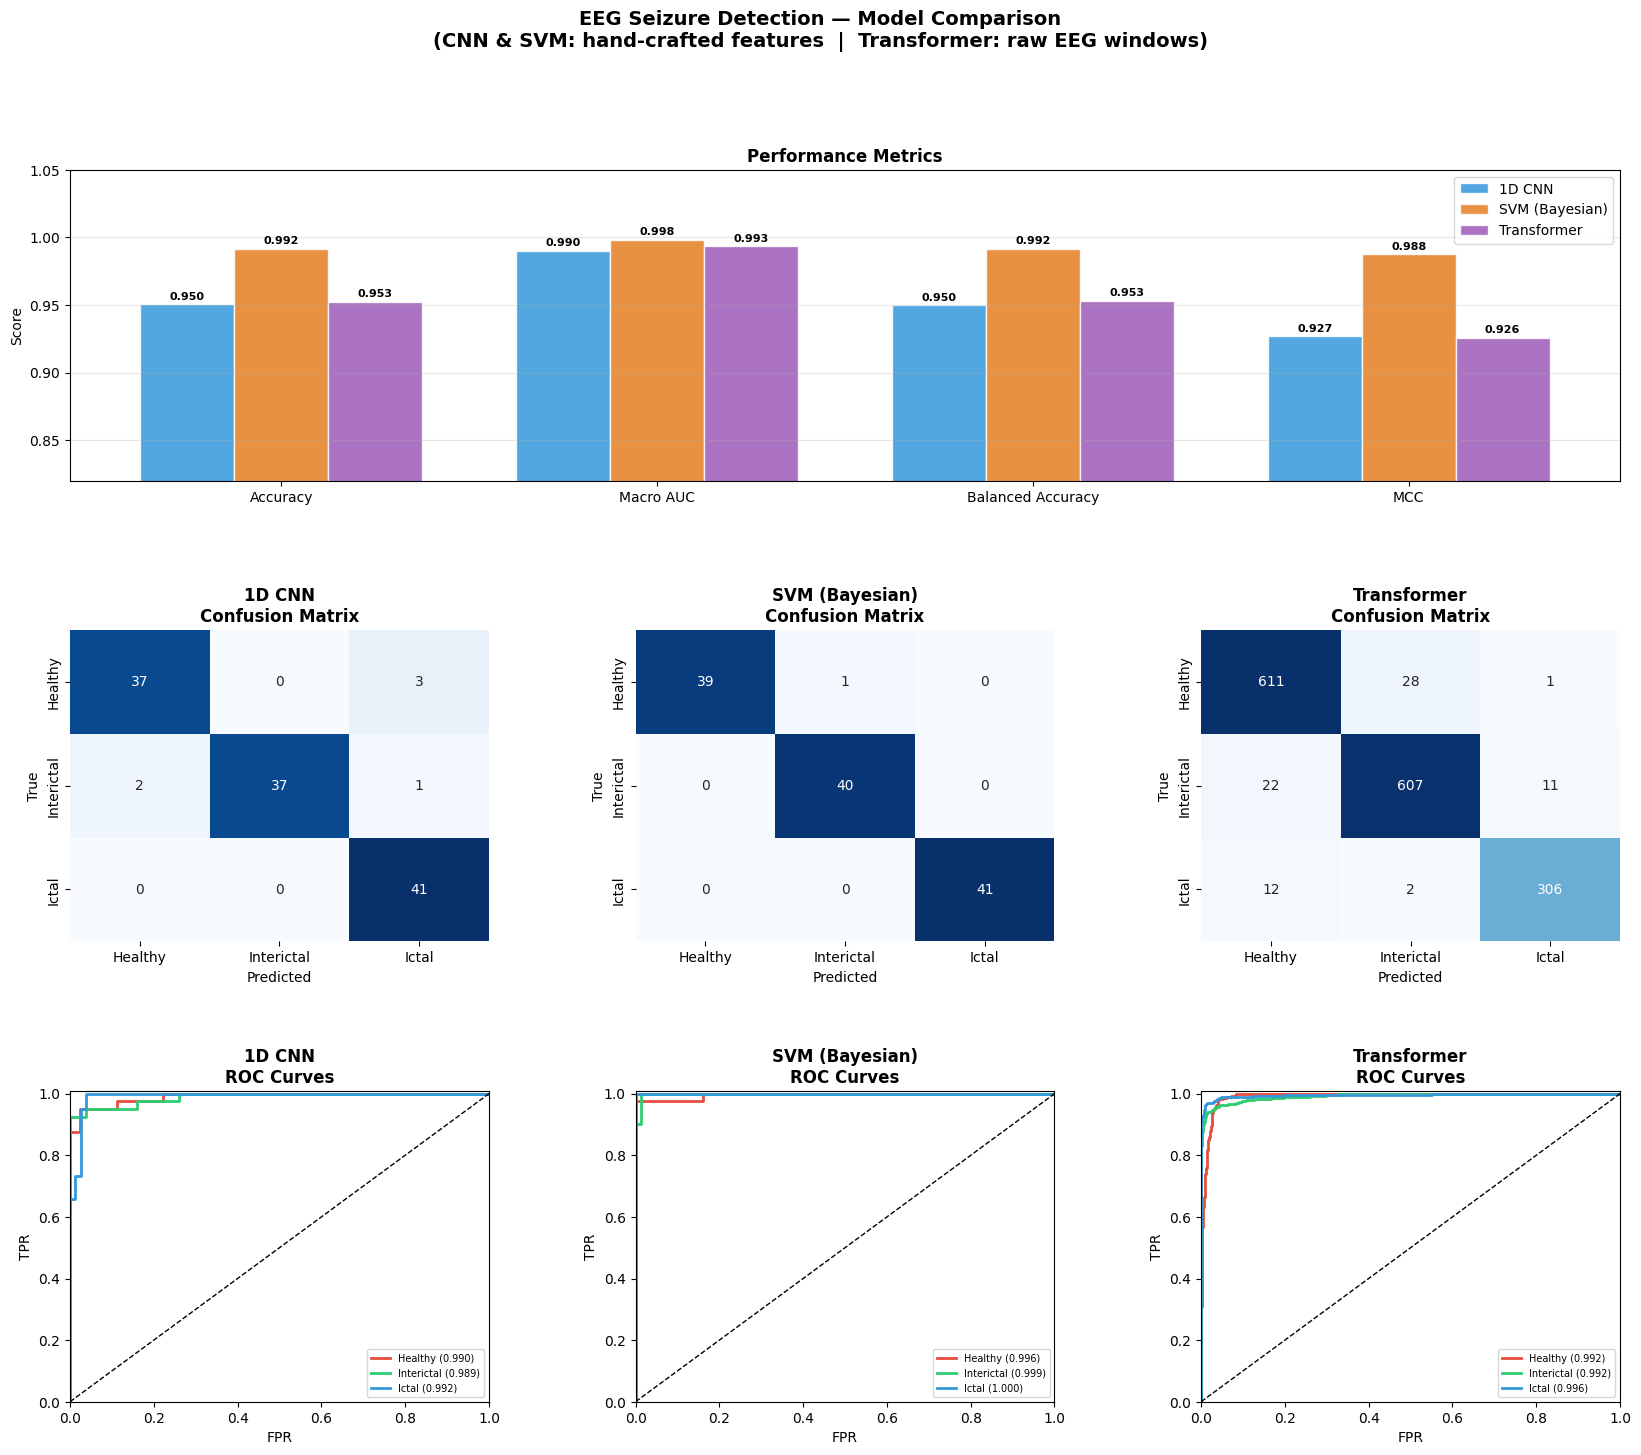

Saved → all_models_comparison.png


In [14]:
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.35)
fig.suptitle(
    'EEG Seizure Detection — Model Comparison\n'
    '(CNN & SVM: hand-crafted features  |  Transformer: raw EEG windows)',
    fontsize=14, fontweight='bold', y=0.98
)

# Row 1: grouped bar chart
ax_bar = fig.add_subplot(gs[0, :])
x = np.arange(len(metrics))
w = 0.25
for i, m in enumerate(models):
    vals = [float(results[m][met] or 0) for met in metrics]
    bars = ax_bar.bar(x + i*w, vals, w, label=m,
                      color=results[m]['color'], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax_bar.set_xticks(x + w); ax_bar.set_xticklabels(metrics)
ax_bar.set_ylim(0.82, 1.05); ax_bar.set_ylabel('Score')
ax_bar.set_title('Performance Metrics', fontweight='bold')
ax_bar.legend(); ax_bar.grid(axis='y', alpha=0.3)

# Row 2: confusion matrices
for ci, (m_name, m_data) in enumerate(results.items()):
    ax = fig.add_subplot(gs[1, ci])
    if m_data['preds'] is not None:
        cm = confusion_matrix(m_data['y_true'], m_data['preds'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                    ax=ax, cbar=False, annot_kws={'size': 10})
    else:
        ax.text(0.5, 0.5, 'Published results only',
                ha='center', va='center', transform=ax.transAxes)
    ax.set_title(f'{m_name}\nConfusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

# Row 3: ROC curves
cls_colors = ['#e74c3c', '#2ecc71', '#3498db']
for ci, (m_name, m_data) in enumerate(results.items()):
    ax = fig.add_subplot(gs[2, ci])
    if m_data['probs'] is not None and m_data['y_bin'] is not None:
        for ki, (cls, cc) in enumerate(zip(CLASS_NAMES, cls_colors)):
            fpr, tpr, _ = roc_curve(m_data['y_bin'][:, ki], m_data['probs'][:, ki])
            auc_i = roc_auc_score(m_data['y_bin'][:, ki], m_data['probs'][:, ki])
            ax.plot(fpr, tpr, color=cc, lw=2, label=f'{cls} ({auc_i:.3f})')
        ax.plot([0,1],[0,1],'k--', lw=1)
        ax.legend(loc='lower right', fontsize=7)
    else:
        ax.text(0.5, 0.5, f'Macro AUC = {m_data["Macro AUC"]:.4f}\n(published)',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.01])
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'{m_name}\nROC Curves', fontweight='bold')

plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → all_models_comparison.png')

## 12. Per-Class F1 Breakdown

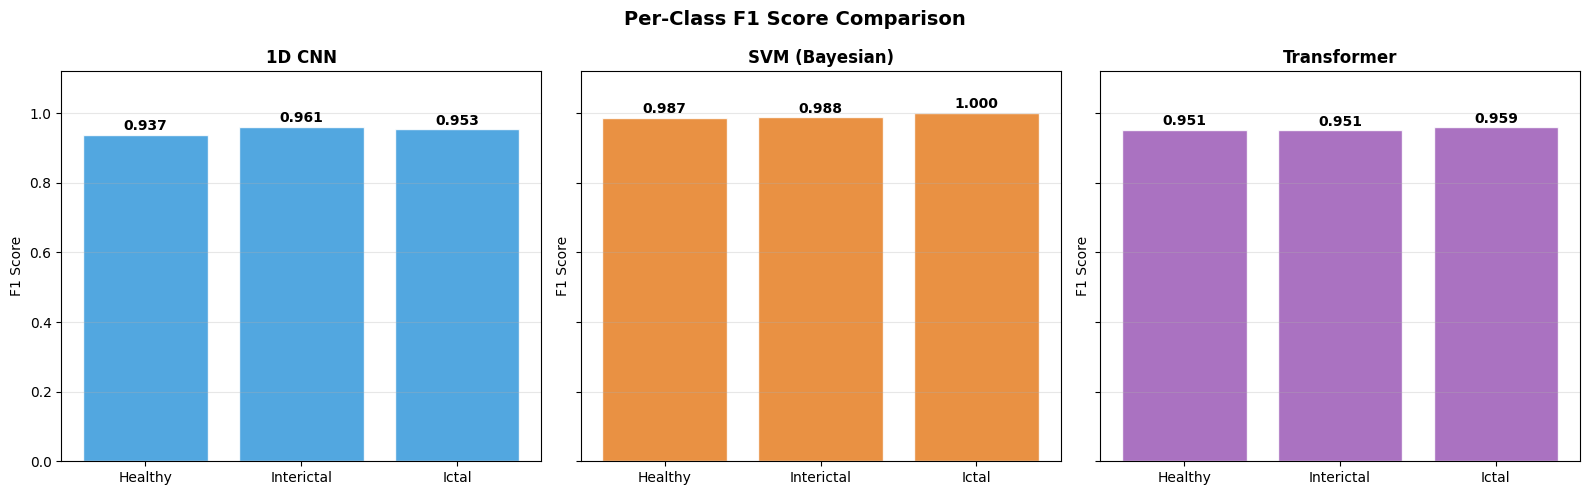

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Per-Class F1 Score Comparison', fontsize=14, fontweight='bold')
for ax, (m_name, m_data) in zip(axes, results.items()):
    if m_data['preds'] is not None:
        f1s  = f1_score(m_data['y_true'], m_data['preds'], average=None)
        bars = ax.bar(CLASS_NAMES, f1s, color=m_data['color'], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, f1s):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
        ax.set_ylim(0, 1.12)
    else:
        ax.text(0.5, 0.5, 'Published results only',
                ha='center', va='center', transform=ax.transAxes)
    ax.set_title(m_name, fontweight='bold')
    ax.set_ylabel('F1 Score'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_f1_comparison.png', dpi=150)
plt.show()

## 13. Attention Visualisation

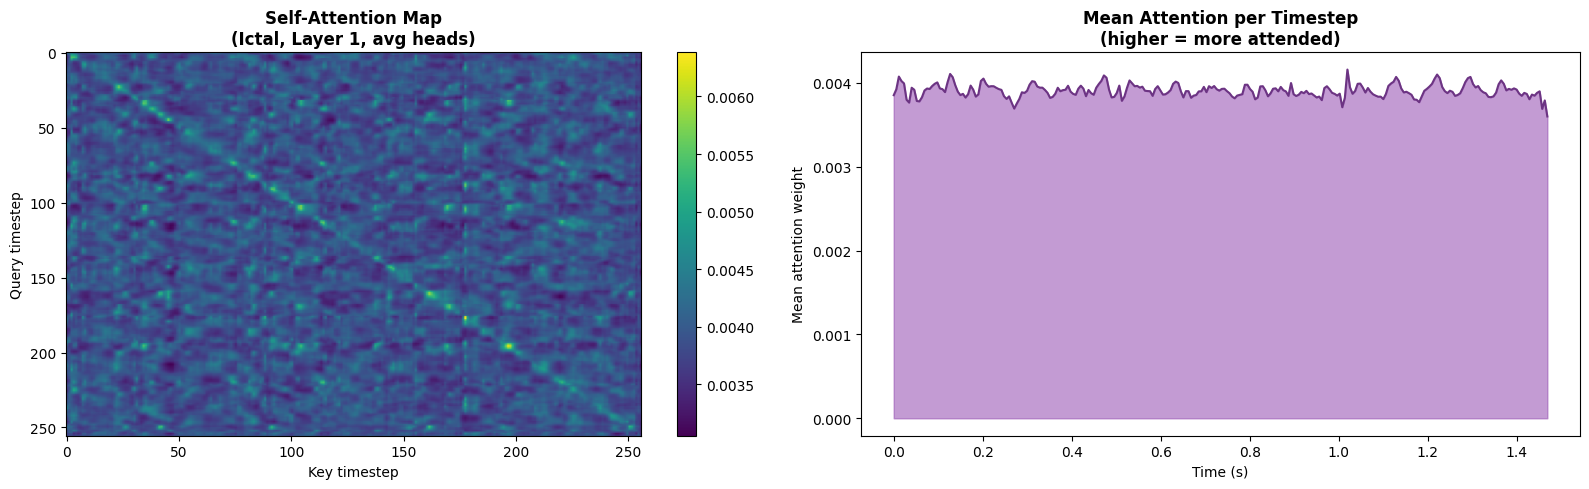

Saved → transformer_attention_map.png


In [16]:
try:
    inp_a = keras.Input(shape=(T, C))
    x_a   = layers.Conv1D(64, kernel_size=7, padding='same', activation='relu')(inp_a)
    x_a   = layers.LayerNormalization(epsilon=1e-6)(x_a)
    x_a   = PositionalEncoding(T, 64)(x_a)
    mha   = layers.MultiHeadAttention(num_heads=4, key_dim=16)
    _, attn_scores = mha(x_a, x_a, return_attention_scores=True)
    attn_model = Model(inp_a, attn_scores)
    mha.set_weights(transformer.get_layer('block_0').attn.get_weights())

    ictal_idx = np.where(y_te == 2)[0][:8]
    scores    = attn_model.predict(X_te[ictal_idx], verbose=0)   # (8, heads, T, T)
    avg_attn  = scores.mean(axis=(0, 1))                          # (T, T)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    im = axes[0].imshow(avg_attn, aspect='auto', cmap='viridis', origin='upper')
    plt.colorbar(im, ax=axes[0])
    axes[0].set_title('Self-Attention Map\n(Ictal, Layer 1, avg heads)', fontweight='bold')
    axes[0].set_xlabel('Key timestep'); axes[0].set_ylabel('Query timestep')

    mean_attn = avg_attn.mean(axis=0)
    t_axis = np.arange(T) / FS
    axes[1].fill_between(t_axis, mean_attn, alpha=0.6, color='#9b59b6')
    axes[1].plot(t_axis, mean_attn, color='#6c3483', lw=1.5)
    axes[1].set_title('Mean Attention per Timestep\n(higher = more attended)', fontweight='bold')
    axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Mean attention weight')

    plt.tight_layout()
    plt.savefig('transformer_attention_map.png', dpi=150)
    plt.show()
    print('Saved → transformer_attention_map.png')
except Exception as e:
    print(f'Attention visualisation skipped: {e}')

## 14. Save Everything

In [19]:
transformer.save('transformer_eeg_model.keras')

summary = {
    m: {k: (float(results[m][k]) if results[m][k] is not None else None)
        for k in metrics}
    for m in models
}
with open('model_comparison_results.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Outputs:')
for fname in [
    'transformer_eeg_model.keras',
    'transformer_training_curves.png',
    'transformer_evaluation.png',
    'all_models_comparison.png',
    'per_class_f1_comparison.png',
    'transformer_attention_map.png',
    'model_comparison_results.json'
]:
    print(f'  {"yay saved" if os.path.exists(fname) else "nay"}  {fname}')

Outputs:
  yay saved  transformer_eeg_model.keras
  yay saved  transformer_training_curves.png
  yay saved  transformer_evaluation.png
  yay saved  all_models_comparison.png
  yay saved  per_class_f1_comparison.png
  yay saved  transformer_attention_map.png
  yay saved  model_comparison_results.json
